In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

os.makedirs("models", exist_ok=True)
os.makedirs("reports/model", exist_ok=True)

print("✅ All imports successful")

✅ All imports successful


In [5]:
X_train = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\X_train.csv")
X_test  = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\X_test.csv")
y_train = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\y_train.csv").squeeze()
y_test  = pd.read_csv("C:\\Users\\hp\\Desktop\\Mini Project - sem 6\\data\\processed\\y_test.csv").squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test distribution:\n{y_test.value_counts()}")

X_train: (16000, 47) | X_test: (4000, 47)
y_train distribution:
LoanApproved
0    12176
1     3824
Name: count, dtype: int64
y_test distribution:
LoanApproved
0    3044
1     956
Name: count, dtype: int64


In [6]:
scale_pos_weight = 15220 / 4780  # ratio of negatives to positives

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

print("✅ Models defined")

✅ Models defined


In [7]:
results = {}

for name, model in models.items():
    print(f"\n--- Training: {name} ---")
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":           accuracy_score(y_test, y_pred),
        "Precision (App=1)":  precision_score(y_test, y_pred, pos_label=1),
        "Recall (App=1)":     recall_score(y_test, y_pred, pos_label=1),
        "F1 (App=1)":         f1_score(y_test, y_pred, pos_label=1),
        "ROC-AUC":            roc_auc_score(y_test, y_proba),
        "model":              model,
        "y_pred":             y_pred,
        "y_proba":            y_proba
    }

    print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))
    print(f"ROC-AUC: {results[name]['ROC-AUC']:.4f}")

print("\n✅ All models trained and evaluated")


--- Training: Logistic Regression ---
              precision    recall  f1-score   support

    Rejected       0.99      0.96      0.97      3044
    Approved       0.88      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000

ROC-AUC: 0.9948

--- Training: Decision Tree ---
              precision    recall  f1-score   support

    Rejected       0.93      0.93      0.93      3044
    Approved       0.77      0.77      0.77       956

    accuracy                           0.89      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.89      0.89      0.89      4000

ROC-AUC: 0.8466

--- Training: Random Forest ---
              precision    recall  f1-score   support

    Rejected       0.93      0.97      0.95      3044
    Approved       0.90      0.78      0.84       956

    accuracy                           0.93  

In [8]:
summary_cols = ["Accuracy", "Precision (App=1)", "Recall (App=1)", "F1 (App=1)", "ROC-AUC"]
summary_df = pd.DataFrame(
    {name: {k: v for k, v in metrics.items() if k in summary_cols}
     for name, metrics in results.items()}
).T.round(4)

print("\n📊 Model Comparison Summary:")
print(summary_df.to_string())


📊 Model Comparison Summary:
                     Accuracy  Precision (App=1)  Recall (App=1)  F1 (App=1)  ROC-AUC
Logistic Regression    0.9608             0.8765          0.9728      0.9222   0.9948
Decision Tree          0.8882             0.7659          0.7667      0.7663   0.8466
Random Forest          0.9275             0.9041          0.7793      0.8371   0.9783
XGBoost                0.9545             0.8870          0.9278      0.9070   0.9907


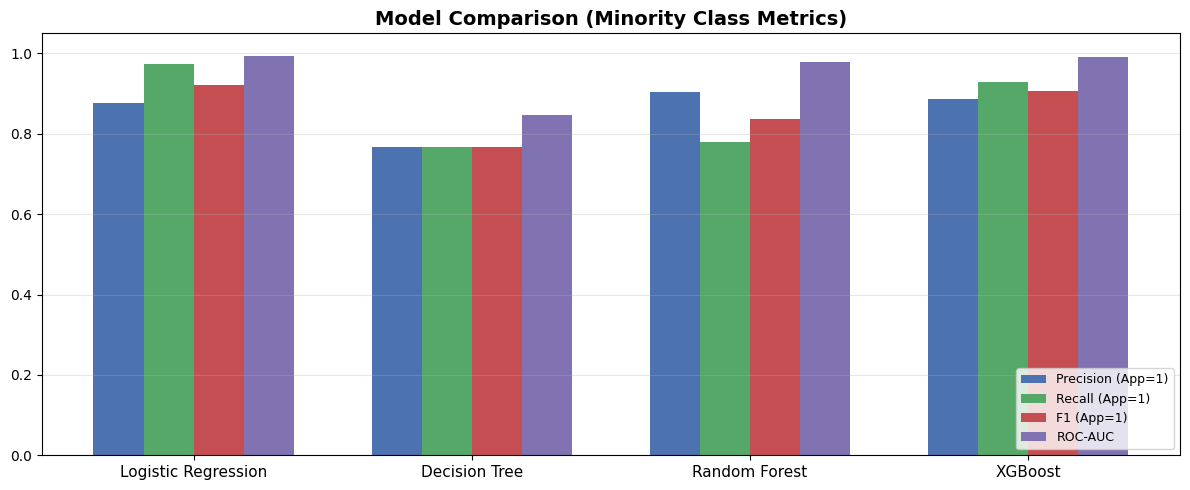

✅ Saved: reports/model/comparison.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

x    = np.arange(len(summary_df))
width = 0.18
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for i, col in enumerate(summary_cols[1:]):   # skip raw Accuracy
    ax.bar(x + i * width, summary_df[col], width, label=col, color=colors[i % len(colors)])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary_df.index, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison (Minority Class Metrics)", fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("reports/model/comparison.png", dpi=150)
plt.show()
print("✅ Saved: reports/model/comparison.png")

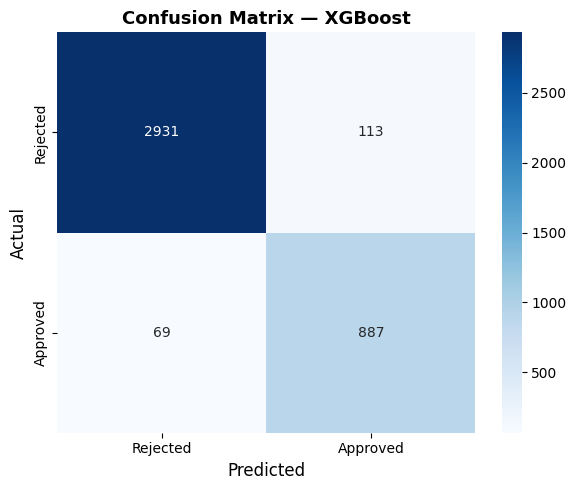

✅ Saved: reports/model/confusion_matrix.png


In [10]:
best_name  = "XGBoost"
best_data  = results[best_name]

cm = confusion_matrix(y_test, best_data["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"], ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("reports/model/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: reports/model/confusion_matrix.png")

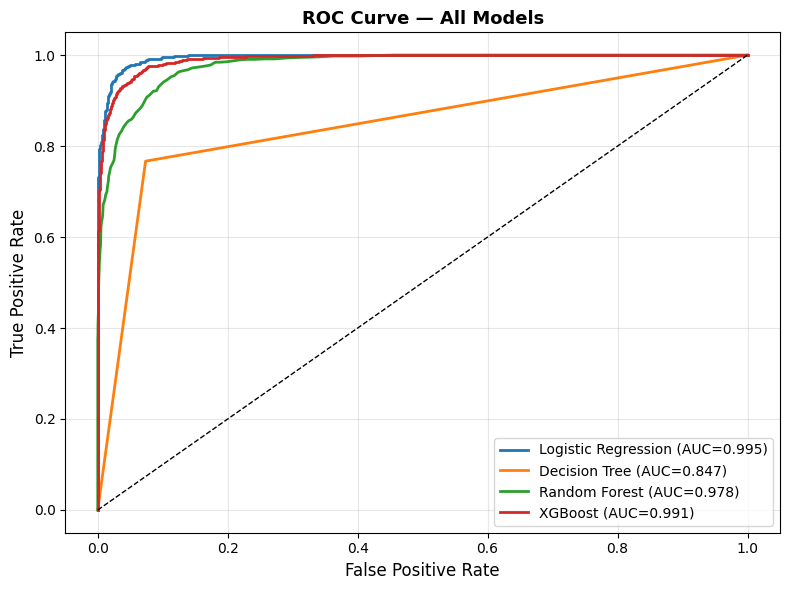

✅ Saved: reports/model/roc_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, data in results.items():
    fpr, tpr, _ = roc_curve(y_test, data["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={data['ROC-AUC']:.3f})", lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — All Models", fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("reports/model/roc_curve.png", dpi=150)
plt.show()
print("✅ Saved: reports/model/roc_curve.png")